# Project Title:
### Comprehensive BigBasket E-Commerce Product Analytics

# Problem Statement:
### The goal is to analyze BigBasket’s product data to identify category trends, pricing patterns, and customer rating behaviours in order to uncover opportunities that can improve product positioning, pricing decisions, and customer satisfaction in the online grocery market.

# Importing libraries and data

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/Users/Sumedh/Downloads/BigBasket Products.csv")
# preview first 5 rows
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


# Check column names and data types

In [65]:
# check column names
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

In [66]:
# renaming index column to id 
df=df.rename(columns={"index":"id"})

In [67]:
df.columns

Index(['id', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

In [68]:
# check data types
df.dtypes

id                int64
product          object
category         object
sub_category     object
brand            object
sale_price      float64
market_price    float64
type             object
rating          float64
description      object
dtype: object

# Data overview

In [69]:
# checking rows and columns
df.shape

(27555, 10)

In [70]:
# checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [71]:
# checking null values
df.isnull().sum()

id                 0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description      115
dtype: int64

In [72]:
# checking duplicate values
df.duplicated().sum()

0

# Data Cleaning

## Remove leading/trailing spaces

In [73]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()


## Fix encoding errors

In [74]:
def fix_encoding(x):
    try:
        return x.encode('latin1', 'ignore').decode('utf-8', 'ignore')
    except:
        return x

df['product'] = df['product'].apply(fix_encoding)
df['description'] = df['description'].apply(fix_encoding)


## Remove truncated text (“...”)

In [75]:
df['product'] = df['product'].str.replace("...", "", regex=False)
df['description'] = df['description'].str.replace("...", "", regex=False)


## Handling missing values

In [76]:
df['rating'] = df['rating'].fillna(df['rating'].median())
df['description'] = df['description'].fillna("No description available")
df['brand'] = df['brand'].fillna("Unknown")
df['product'] = df['product'].fillna("Unnamed Product")


## Standardize columns

In [77]:
df['brand'] = df['brand'].str.title()
df['product'] = df['product'].str.title()


## Flag short descriptions

In [78]:
df['description_length'] = df['description'].str.len()
df['short_description'] = df['description_length'] < 40


## Flag extremely long descriptions

In [79]:
df['long_description'] = df['description_length'] > 300


## Rare brand detection

In [80]:
brand_counts = df['brand'].value_counts()
df['rare_brand'] = df['brand'].map(brand_counts) == 1


## Export cleaned data

In [81]:
df.to_csv("/Users/Sumedh/Downloads/Big basket project/Cleaned data/bigbasket_cleaned.csv", 
          index=False)


# Exploratory Data Analysis

## 1. Which categories contribute the most to BigBasket’s assortment?

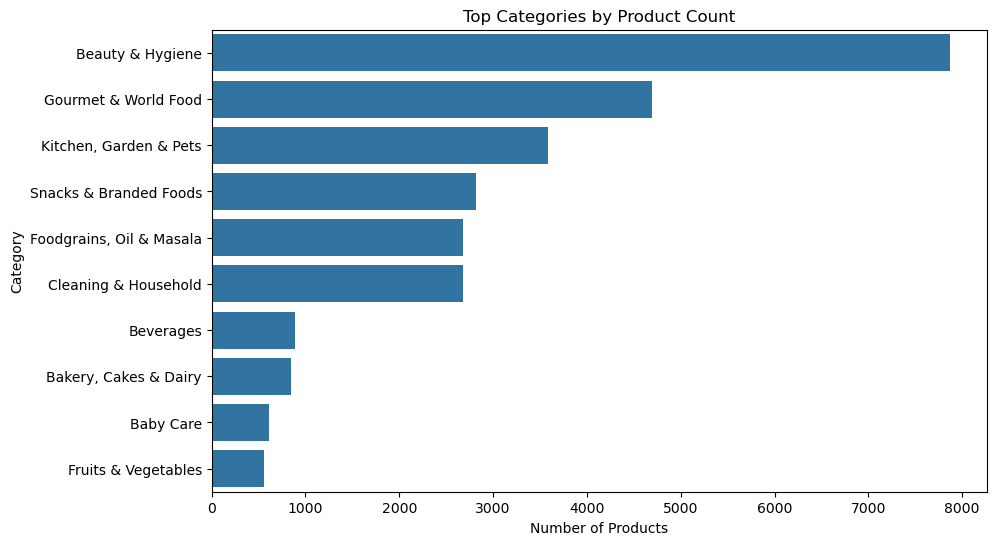

In [82]:
# Group by category and calculate product count, avg price, avg rating
category_summary = (
    df.groupby('category')
      .agg(product_count=('product','count'),
           avg_price=('sale_price','mean'),
           avg_rating=('rating','mean'))
      .sort_values('product_count', ascending=False)
)

# Plot top 10 categories by number of products
plt.figure(figsize=(10,6))
sns.barplot(data=category_summary.reset_index().head(10),
            x='product_count', y='category')
plt.title("Top Categories by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()



### Insights
- Beauty and Hygiene has the highest number of listed products, showing it is BigBaskets most heavily expanded and diverse category.
- Gourmet and World Food and Kitchen, Garden and Pets also have strong product depth, indicating high consumer demand and strategic focus.
- Categories such as Fruits and Vegetables and Baby Care have fewer products, suggesting limited assortment or tighter product curation.


## 2. Which brands dominate the platform in terms of product volume?

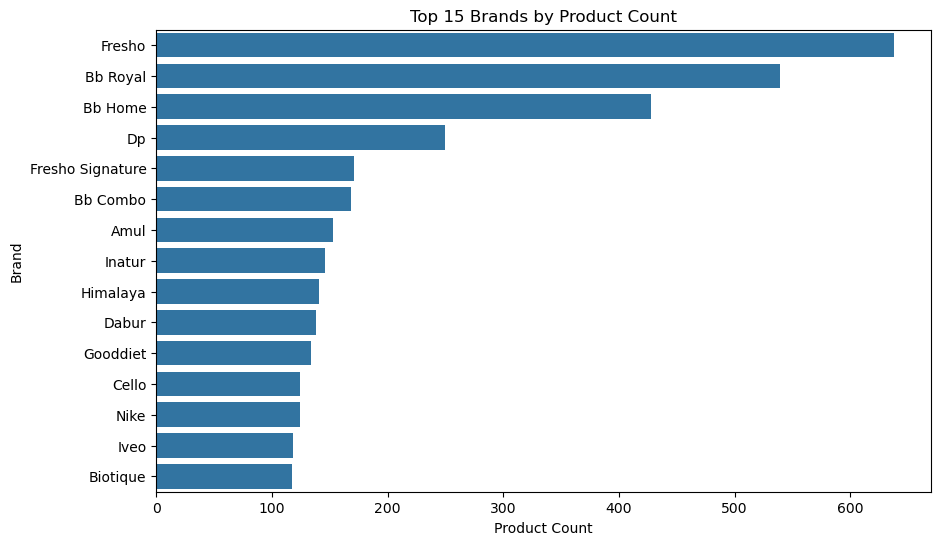

In [83]:
# Count how many products each brand has
brand_summary = df['brand'].value_counts().head(15)

# Plot the top 15 brands
plt.figure(figsize=(10,6))
sns.barplot(x=brand_summary.values, y=brand_summary.index)
plt.title("Top 15 Brands by Product Count")
plt.xlabel("Product Count")
plt.ylabel("Brand")
plt.show()


### Insights
- Fresho, Bb Royal, and Bb Home dominate the product catalog, showing BigBasket’s strong emphasis on private-label brands.  
- These top brands have significantly higher product counts than national brands like Amul, Himalaya, and Dabur, indicating a strategy to push in-house products with better margins.  
- Brands with lower product counts, such as Cello, Nike, Iveo, and Biotique, contribute less to the assortment, suggesting limited category presence or selective listing.


## 3. What is the overall price distribution?

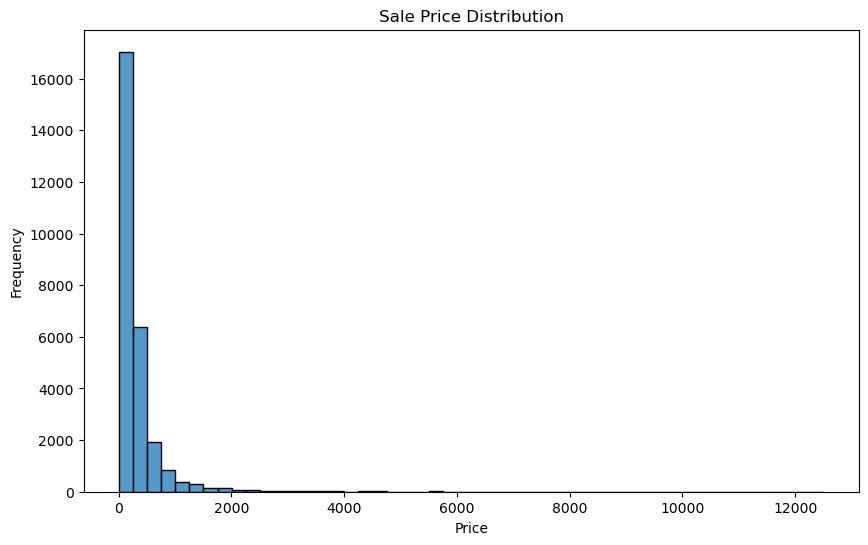

In [84]:
# Basic histogram of sale price to understand price range
plt.figure(figsize=(10,6))
sns.histplot(df['sale_price'], bins=50)
plt.title("Sale Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


### Insights
- The sale price distribution is heavily right-skewed, with the majority of BigBasket products priced below 500 INR.  
- Only a small portion of items fall into higher price ranges (above 2000 INR), indicating that premium or luxury products form a very small segment of the catalog.  
- This pricing pattern shows BigBasket’s focus on affordable, high-volume FMCG items rather than high-priced specialty goods.


## 4. Which categories have the highest customer satisfaction?

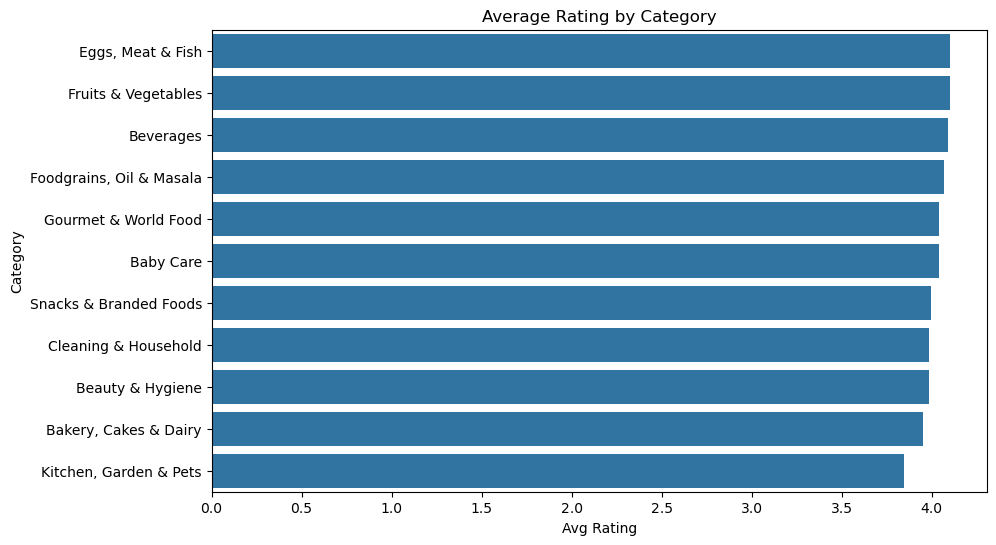

In [85]:
# Calculate average rating for each category
category_rating = (
    df.groupby('category')['rating']
      .mean()
      .sort_values(ascending=False)
)

# Plot ratings by category
plt.figure(figsize=(10,6))
sns.barplot(x=category_rating.values, y=category_rating.index)
plt.title("Average Rating by Category")
plt.xlabel("Avg Rating")
plt.ylabel("Category")
plt.show()


### Insights
- Most categories have an average rating close to 4, indicating strong overall customer satisfaction across BigBasket’s product range.  
- Eggs, Meat & Fish and Fruits & Vegetables are among the highest-rated categories, suggesting customers trust BigBasket’s fresh and perishable items.  
- Kitchen, Garden & Pets has the lowest average rating, which may indicate quality concerns or inconsistent customer experience in these product types.


## 5. Which categories offer the highest discounts?

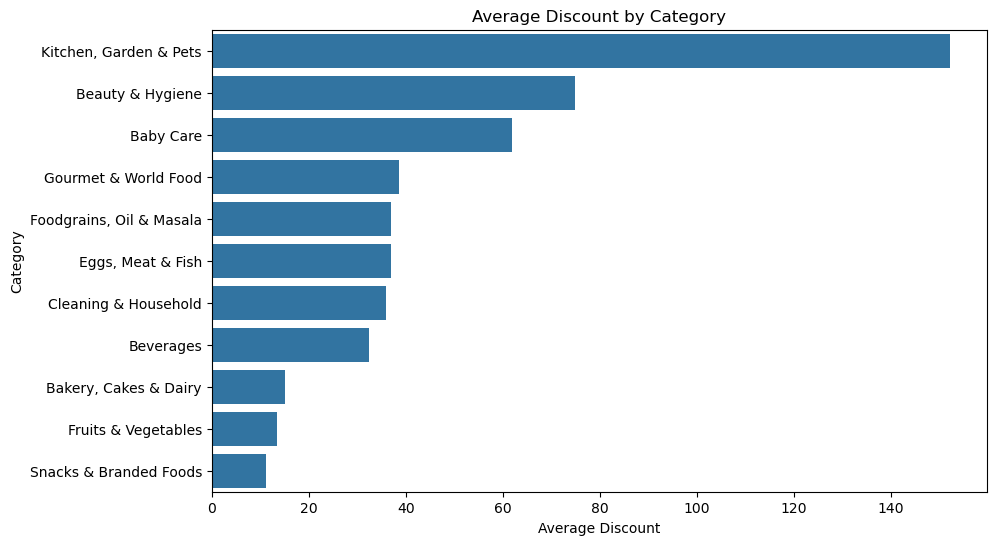

In [86]:
# Calculate discount for each product
df['discount'] = df['market_price'] - df['sale_price']

# Average discount by category
category_discount = (
    df.groupby('category')['discount']
      .mean()
      .sort_values(ascending=False)
)

# Plot results
plt.figure(figsize=(10,6))
sns.barplot(x=category_discount.values, y=category_discount.index)
plt.title("Average Discount by Category")
plt.xlabel("Average Discount")
plt.ylabel("Category")
plt.show()


### Insights
- Kitchen, Garden & Pets shows the highest average discount by a large margin, suggesting aggressive pricing to boost sales or clear slow-moving inventory.  
- Beauty & Hygiene and Baby Care also receive relatively high discounts, indicating competitive pricing in these categories.  
- Categories like Snacks & Branded Foods and Fruits & Vegetables have minimal discounts, reflecting strong demand or stable pricing with less need for promotional push.


## 6. Which product types have the highest price variability?

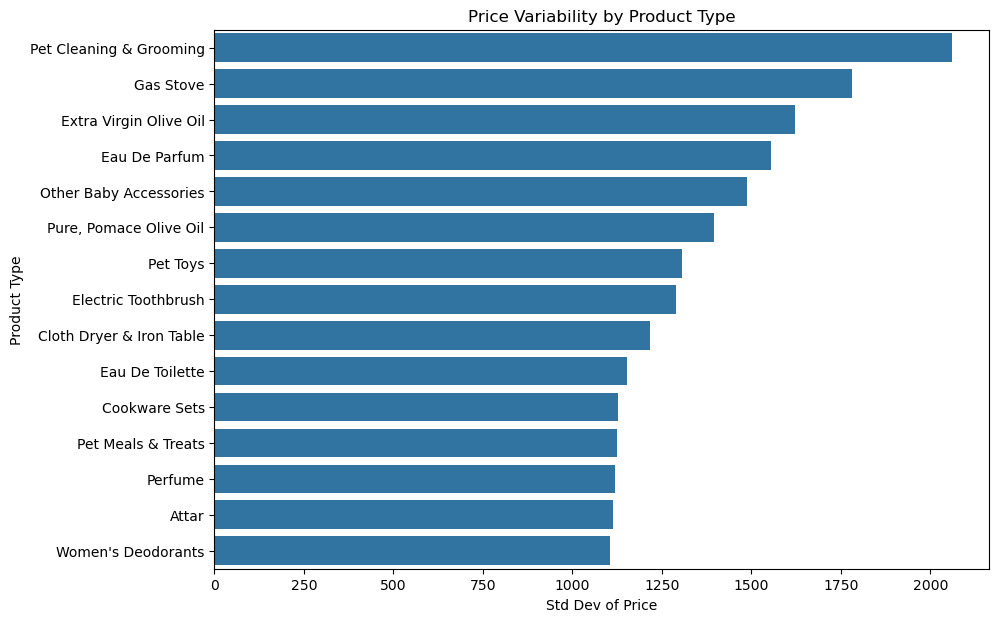

In [87]:
# Standard deviation of sale price shows price volatility
price_variability = (
    df.groupby('type')['sale_price']
      .std()
      .sort_values(ascending=False)
      .head(15)
)

# Plot top 15 most variable product types
plt.figure(figsize=(10,7))
sns.barplot(x=price_variability.values, y=price_variability.index)
plt.title("Price Variability by Product Type")
plt.xlabel("Std Dev of Price")
plt.ylabel("Product Type")
plt.show()


### Insights
- Cleaning & Grooming products show the highest price variability, indicating a wide mix of premium and budget items within the category.  
- Gas Stoves and Olive Oil variants also display high price fluctuation, likely due to differences in size, brand positioning, and product quality tiers.  
- Categories like Pet Meals, Perfume, and Attar have relatively lower variability compared to the top segments, suggesting more consistent pricing within these product types.


## 7. Does price influence customer ratings?

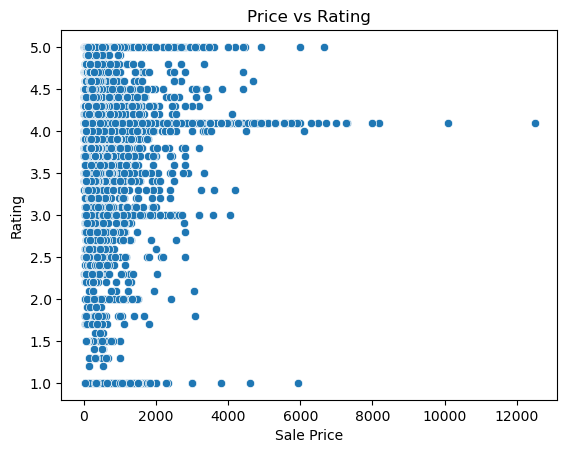

In [88]:
# Scatter plot to visually check relationship between price and rating
sns.scatterplot(data=df, x='sale_price', y='rating')
plt.title("Price vs Rating")
plt.xlabel("Sale Price")
plt.ylabel("Rating")
plt.savefig("7.png")
plt.show()


### Insights
- There is no clear relationship between sale price and rating, indicating that customers rate products based on quality and experience rather than price.  
- Both low-priced and high-priced products receive a wide range of ratings, showing that affordability does not guarantee higher satisfaction.  
- A dense cluster of highly rated items exists in the lower price range, suggesting strong customer approval for budget-friendly FMCG products.


## 8. Which sub-categories have the lowest average ratings?

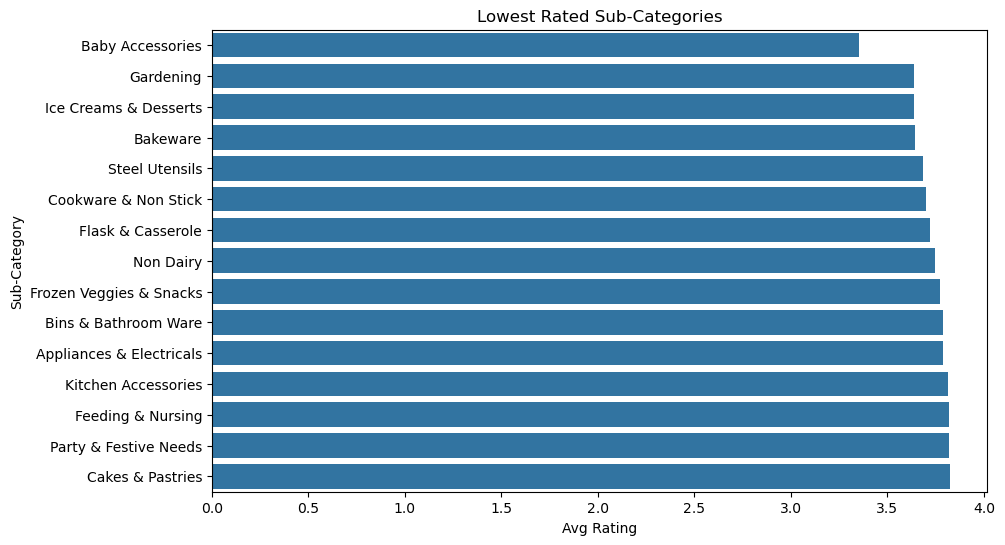

In [89]:
# Calculate average rating for each sub-category
subcategory_rating = (
    df.groupby('sub_category')['rating']
      .mean()
      .sort_values()
      .head(15)
)

# Plot lowest-rated subcategories
plt.figure(figsize=(10,6))
sns.barplot(x=subcategory_rating.values, y=subcategory_rating.index)
plt.title("Lowest Rated Sub-Categories")
plt.xlabel("Avg Rating")
plt.ylabel("Sub-Category")
plt.show()


### Insights
- Baby Accessories has the lowest average rating, indicating possible issues with product quality, usability, or customer expectations in this segment.  
- Several kitchen-related sub-categories such as Bakeware, Steel Utensils, and Cookware show lower ratings, suggesting variability in durability or performance.  
- Gardening and Non Dairy products also appear in the lower-rated list, which may highlight supply inconsistency or customer dissatisfaction with specific product lines.


## 9. Top 20 most discounted products

In [90]:
# Show top 20 highest-discounted products
df.nlargest(20, 'discount')[['product','brand','discount']]


,product,brand,discount
21930,"Premium Cloth Dryer/Drying Stand - Foldable, S...",Dp,4320.00
23082,"Gas Stove-4 Burner Royale Plus Schott Glass, B...",Prestige,4246.00
1056,"Gas Stove-3 Burner Royale Plus Schott Glass, B...",Prestige,3696.00
2343,Induction Base Non Stick Cookware Set With Gla...,Nirlon,3600.00
1789,Induction Base Non Stick Cookware Set With Gla...,Nirlon,3500.00
8759,"Dinner Set - Laser Etched, Premium Stainless S...",Classic Essentials,3500.00
2369,Olive Oil - Extra Light,Borges,2920.00
12430,Olive Oil - Extra Light,Borges,2875.00
13406,3 Burner Gas Stove - Glass Top Manual Ignition...,Pigeon,2796.00
26933,Starter Dry Dog Food - Ultra Premium,Canine Creek,2700.00


### Insights
- High-discount products are dominated by big-ticket household items such as gas stoves, cookware sets, ironing boards, and premium dinner sets, indicating markdowns on higher-priced durable goods.  
- Several olive oil SKUs and premium food items (Borges, Del Monte, Disano, Oleev) also appear in the top discounted list, suggesting price competition in imported or gourmet categories.  
- Luxury personal care and fragrance items (Lalique, Anna Sui, Braun Epilator) are heavily discounted as well, which may reflect low turnover or promotional strategies to increase sales of premium brands.


## 10. How well do sale prices match market prices?

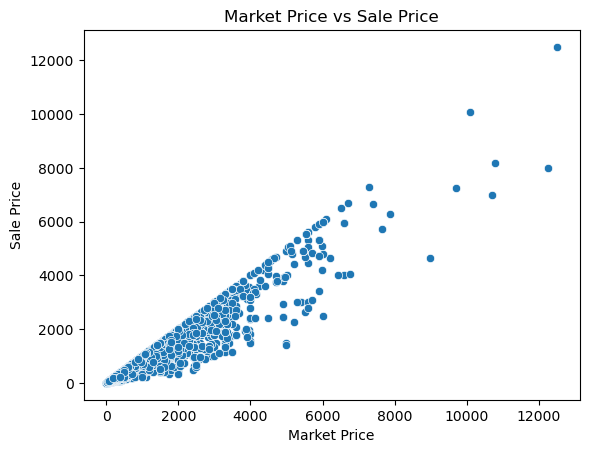

In [91]:
# Scatter plot to compare sale price vs market price
sns.scatterplot(data=df, x='market_price', y='sale_price')
plt.title("Market Price vs Sale Price")
plt.xlabel("Market Price")
plt.ylabel("Sale Price")
plt.show()


### Insights
- There is a strong positive relationship between market price and sale price, showing that discounting follows a consistent pricing structure across products.  
- Most points lie just below the diagonal line, indicating that sale prices are generally slightly lower than market prices, reflecting standard discounting behavior.  
- A few products with significantly lower sale prices compared to market prices suggest heavy markdowns, possibly due to promotions, overstock, or low demand.


## 11. What percentage of products have low-quality descriptions?

In [92]:

# Calculate percentage of products with poor description length
low_quality_pct = df['short_description'].mean() * 100
low_quality_pct


1.2774451097804391

### Insights
- Only about 1.27% of products have short or poor-quality descriptions, indicating that BigBasket maintains strong overall catalog quality.  
- The low percentage suggests that most product listings provide sufficient detail for customers to make purchase decisions.  
- The small set of low-quality descriptions may still impact user trust in certain categories and can be targeted for quick content improvement.


## 12. Which brands rely the most on discounting?

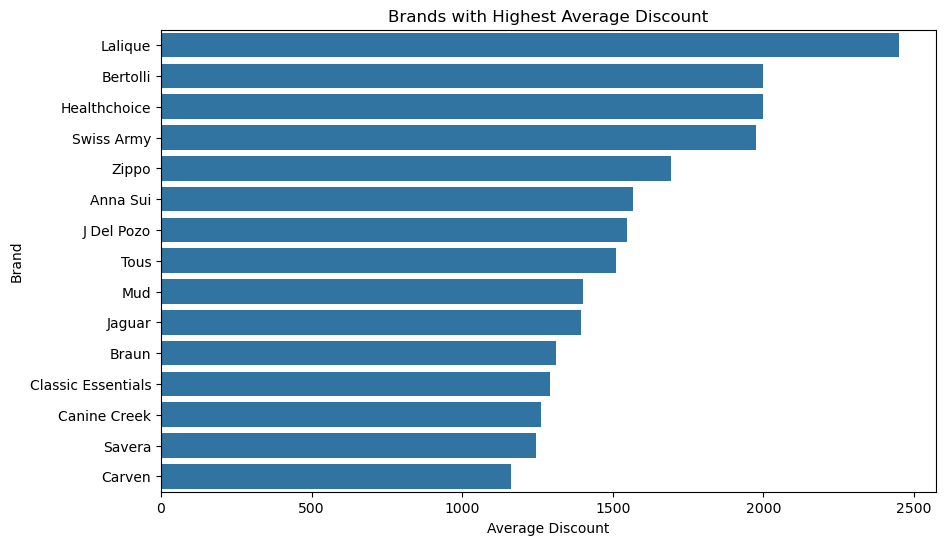

In [93]:
# Average discount by brand
brand_discount = (
    df.groupby('brand')['discount']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

# Plot brands with highest discounting levels
plt.figure(figsize=(10,6))
sns.barplot(x=brand_discount.values, y=brand_discount.index)
plt.title("Brands with Highest Average Discount")
plt.xlabel("Average Discount")
plt.ylabel("Brand")
plt.show()


### Insights
- Lalique, Bertolli, and Healthchoice receive the highest average discounts, suggesting aggressive markdown strategies to increase sales or reduce excess inventory.  
- Several premium or imported brands such as Swiss Army, Zippo, and Anna Sui also show high discounting, indicating slower demand or competitive pricing pressure in their segments.  
- Lower-ranked brands like Savera and Carven still receive substantial discounts, reflecting either promotional activity or lower baseline demand.


## Key Insights Summary
- Beauty & Hygiene has the highest assortment, while Baby Care and Fruits & Vegetables show limited product depth.  
- Private-label brands like Fresho, Bb Royal, and Bb Home dominate listings, reflecting strong in-house brand focus.  
- High-value products (cookware, gas stoves, premium olive oils) receive the highest discounts.  
- Most products are priced below 500 INR and maintain consistently high customer ratings.  
- Only 1.27% of products have poor descriptions, indicating strong catalog maintenance.


## Recommendations
- Expand low-SKU categories such as Baby Care and Fresh Produce to strengthen catalog balance.  
- Improve product quality or vendor selection in low-rated segments like Baby Accessories and Gardening.  
- Review discount strategies for premium items to reduce margin pressure.  
- Fix remaining poor or incomplete descriptions to ensure catalog consistency.


## Conclusion
BigBasket maintains a strong, diverse product portfolio with high customer satisfaction and consistent pricing practices. Private-label brands play a major role in catalog strength. A few areas—mainly low-rated items and heavily discounted premium products—offer opportunities for improvement. Overall, the platform shows robust performance with clear paths for strategic enhancement.
